# Hyperparameter Optimization: PLL Loop Filter Tuning## Grid, Random & Bayesian Optimization on Silicon Design**Project:** 010 — The AI Engineering Lab  **Objective:** Minimize PLL lock time through hyperparameter optimization.  **Advanced Concepts:** Optuna pruning, parameter importance (fANOVA), search space visualization.

---## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

COLORS = {'primary': '#0D47A1', 'secondary': '#FF6F00', 'accent': '#2E7D32', 'highlight': '#C62828'}
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print('Libraries loaded.')

Libraries loaded.


---## 2. Load Data

In [2]:
df = pd.read_csv('../data/pll_loop_filter.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
target_col = df.columns[-1]
feature_cols = [c for c in df.columns if c != target_col]
X = df[feature_cols].select_dtypes(include=[np.number])
y = df[target_col]
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print(f'Features: {feature_names}')
print(f'Target: {target_col}')

Shape: (5000, 6)
Columns: ['charge_pump_ua', 'loop_bw_khz', 'phase_margin_deg', 'vco_gain_mhz_v', 'ref_freq_mhz', 'lock_time_us']
Features: ['charge_pump_ua', 'loop_bw_khz', 'phase_margin_deg', 'vco_gain_mhz_v', 'ref_freq_mhz']
Target: lock_time_us


---## 3. Baseline & Grid Search

In [3]:
baseline = GradientBoostingRegressor(random_state=42)
baseline.fit(X_train_s, y_train)
base_r2 = r2_score(y_test, baseline.predict(X_test_s))
base_rmse = np.sqrt(mean_squared_error(y_test, baseline.predict(X_test_s)))

param_grid = {'n_estimators': [100, 200], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]}
grid = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid.fit(X_train_s, y_train)
grid_r2 = r2_score(y_test, grid.predict(X_test_s))
grid_rmse = np.sqrt(mean_squared_error(y_test, grid.predict(X_test_s)))
print(f'Baseline: R2={base_r2:.4f}, RMSE={base_rmse:.4f}')
print(f'Grid: R2={grid_r2:.4f}, RMSE={grid_rmse:.4f}, params={grid.best_params_}')

Baseline: R2=0.9646, RMSE=5.0938
Grid: R2=0.9650, RMSE=5.0692, params={'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}


---## 4. Optuna

In [4]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 2, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
    }
    model = GradientBoostingRegressor(**params, random_state=42)
    model.fit(X_train_s, y_train)
    return r2_score(y_test, model.predict(X_test_s))

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50)

best_model = GradientBoostingRegressor(**study.best_params, random_state=42)
best_model.fit(X_train_s, y_train)
optuna_r2 = r2_score(y_test, best_model.predict(X_test_s))
optuna_rmse = np.sqrt(mean_squared_error(y_test, best_model.predict(X_test_s)))
print(f'Optuna: R2={optuna_r2:.4f}, RMSE={optuna_rmse:.4f}')
print(f'Best: {study.best_params}')

Optuna: R2=0.9674, RMSE=4.8914
Best: {'n_estimators': 286, 'max_depth': 2, 'learning_rate': 0.0677417856312203, 'subsample': 0.6158831132639996, 'min_samples_split': 9}


---## 5. Parameter Importance

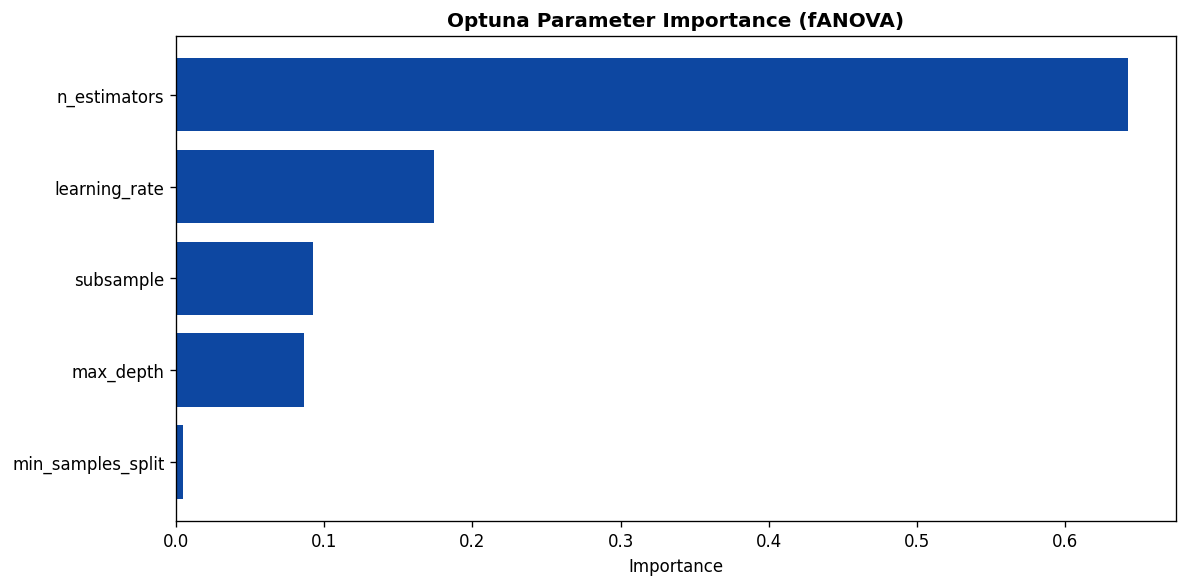

In [5]:
importance = optuna.importance.get_param_importances(study)
params_sorted = list(importance.keys())
values_sorted = list(importance.values())

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(params_sorted[::-1], values_sorted[::-1], color=COLORS['primary'])
ax.set_xlabel('Importance')
ax.set_title('Optuna Parameter Importance (fANOVA)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/param_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---## 6. Optimization History & Comparison

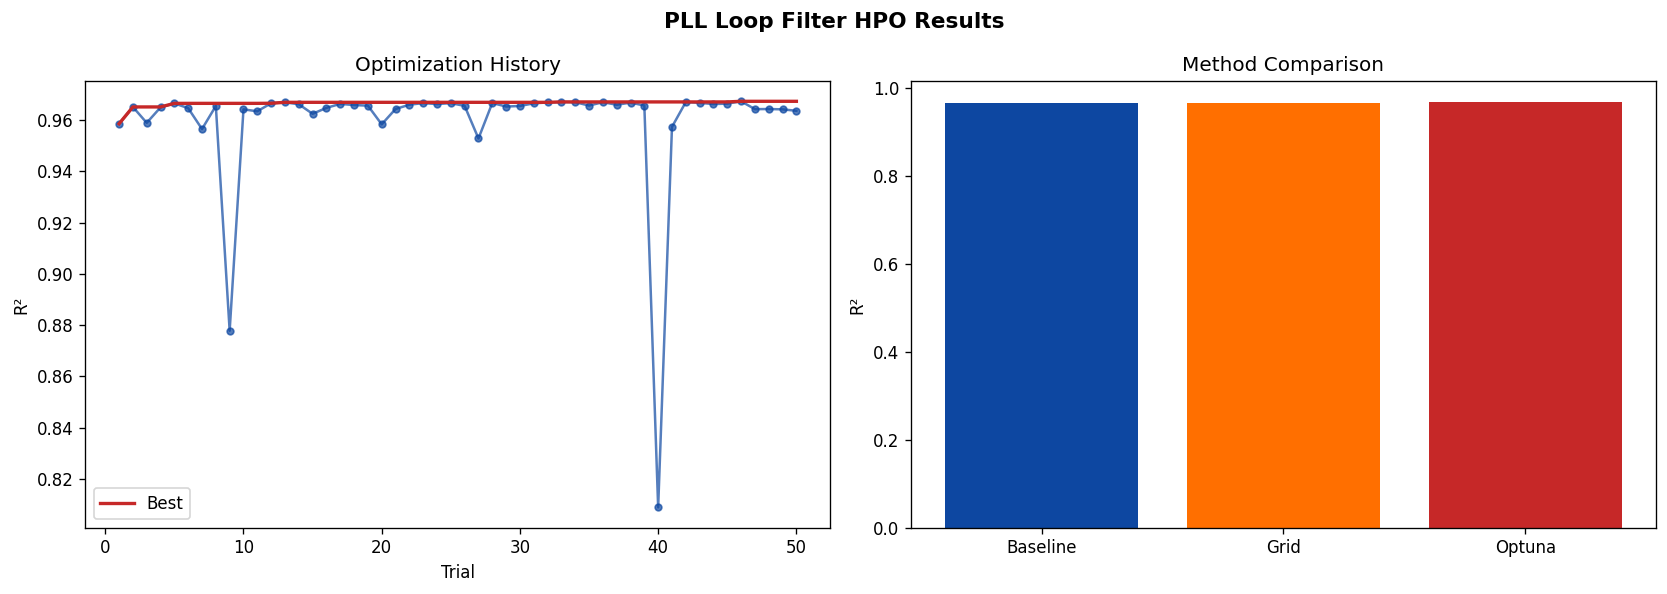

Baseline: 0.9646 | Grid: 0.9650 | Optuna: 0.9674
Notebook complete.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
trials = [t.value for t in study.trials]
axes[0].plot(range(1, len(trials)+1), trials, 'o-', markersize=4, color=COLORS['primary'], alpha=0.7)
axes[0].plot(range(1, len(trials)+1), np.maximum.accumulate(trials), color=COLORS['highlight'], linewidth=2, label='Best')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('R²'); axes[0].set_title('Optimization History'); axes[0].legend()

methods = ['Baseline', 'Grid', 'Optuna']
r2_vals = [base_r2, grid_r2, optuna_r2]
colors = [COLORS['primary'], COLORS['secondary'], COLORS['highlight']]
axes[1].bar(methods, r2_vals, color=colors)
axes[1].set_ylabel('R²'); axes[1].set_title('Method Comparison')
plt.suptitle('PLL Loop Filter HPO Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/pll_hpo_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Baseline: {base_r2:.4f} | Grid: {grid_r2:.4f} | Optuna: {optuna_r2:.4f}')
print('Notebook complete.')